In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("Housing.csv")

# Display first 5 rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
# Shape of the dataset
print("Shape of Dataset:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

Shape of Dataset: (545, 13)

Column Names:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [3]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
# Statistical summary
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
# Check missing values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [6]:
# Total missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [7]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


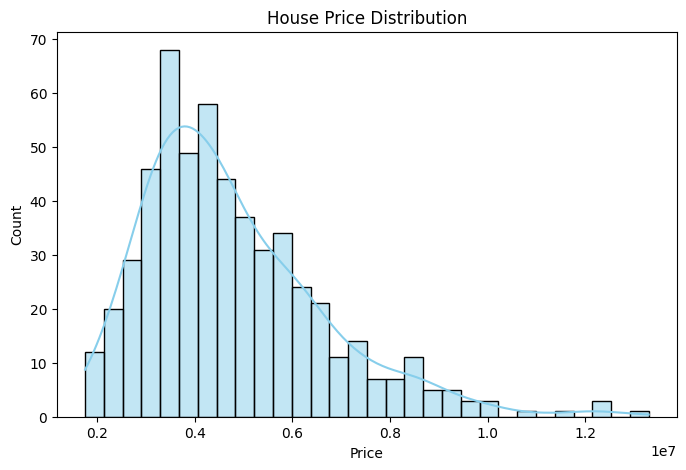

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color='skyblue')

plt.title('House Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')

plt.show()

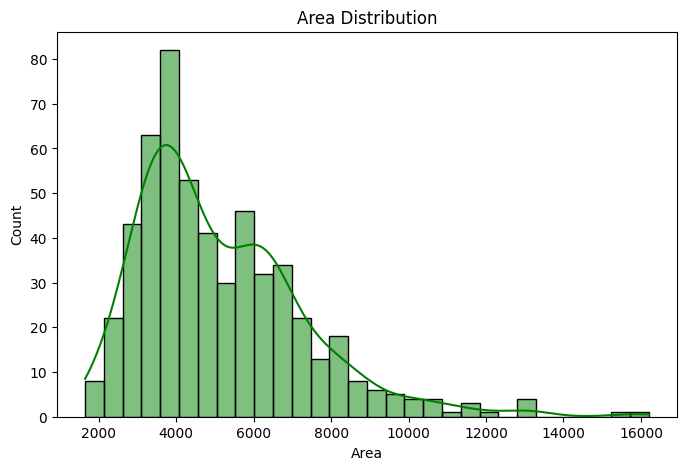

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['area'], bins=30, kde=True, color='green')

plt.title('Area Distribution')
plt.xlabel('Area')
plt.ylabel('Count')

plt.show()

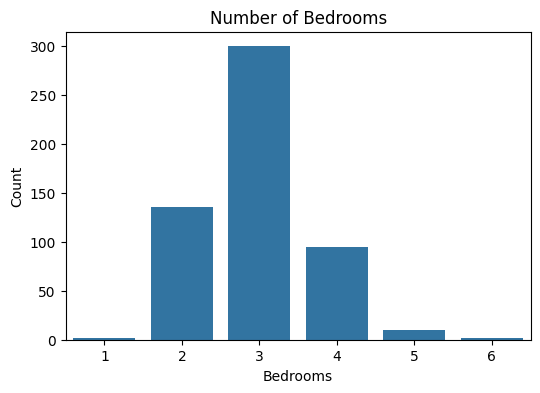

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='bedrooms', data=df)

plt.title('Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Count')

plt.show()

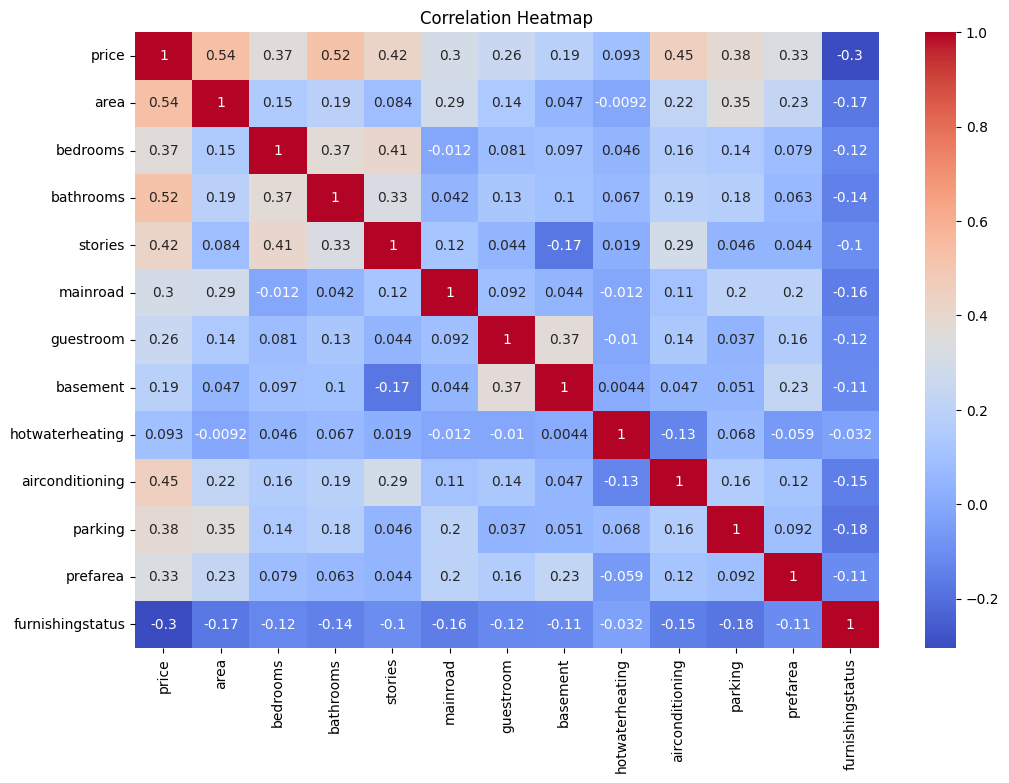

In [11]:
# Convert categorical columns into numeric values
df_encoded = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df_encoded.select_dtypes(include='object').columns:
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset
df_encoded = df.copy()

# Initialize Label Encoder
le = LabelEncoder()

# Encode all categorical columns
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Display first 5 rows
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [13]:
# Features (Independent Variables)
X = df_encoded.drop('price', axis=1)

# Target Variable
y = df_encoded['price']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 12)
Target Shape: (545,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 12)
Testing Data: (109, 12)


In [15]:
from sklearn.linear_model import LinearRegression

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [16]:
# Predict on test data
y_pred = model.predict(X_test)

# Display first 10 predictions
predictions = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

predictions.head(10)

,Actual Price,Predicted Price
0,4060000,5.203692e+06
1,6650000,7.257004e+06
2,3710000,3.062829e+06
3,6440000,4.559592e+06
4,2800000,3.332932e+06
5,4900000,3.563081e+06
6,5250000,5.645466e+06
7,4543000,6.413980e+06
8,2450000,2.755832e+06
9,3353000,2.668939e+06


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-" * 30)
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 3))

Model Performance
------------------------------
Mean Absolute Error (MAE): 979679.69
Mean Squared Error (MSE): 1771751116594.04
Root Mean Squared Error (RMSE): 1331071.42
R² Score: 0.649


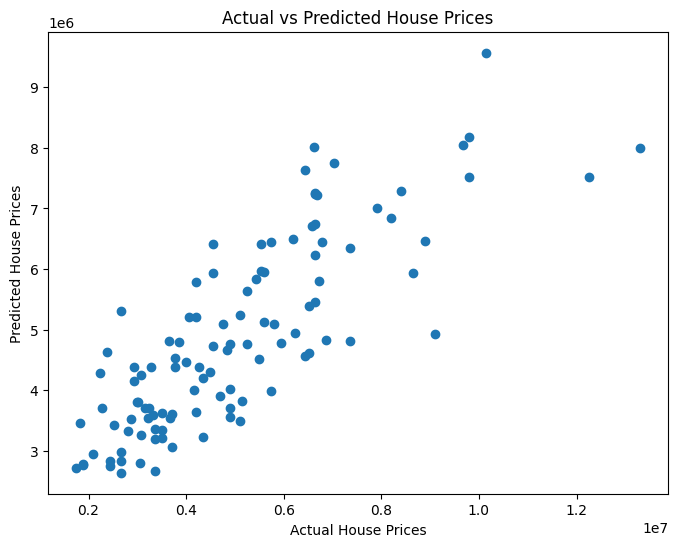

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

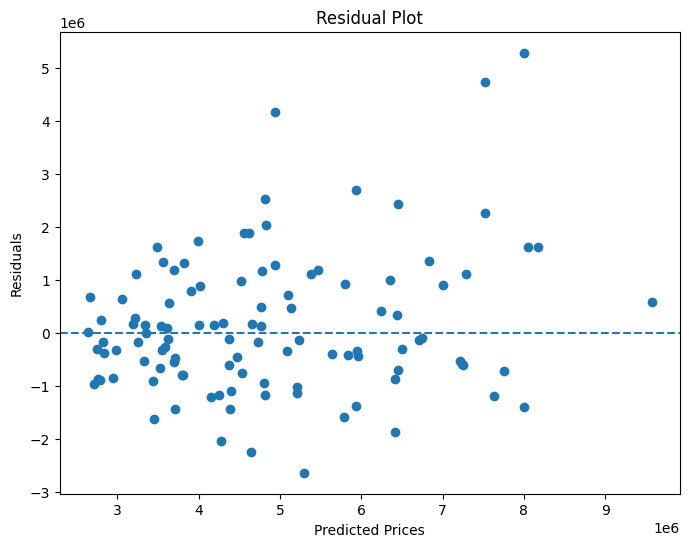

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()